In [3]:
import pandas as pd
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

In [4]:
def agreement_vediff(df):
    ve_by_group = df.groupby(df["group"].str.lower())["variance_explained"].mean()
    human_ve_mean = ve_by_group.get("human", float("nan"))
    llm_ve_mean   = ve_by_group.get("llm", float("nan"))
    ve_diff_llm_minus_human = llm_ve_mean - human_ve_mean
    consensus_by_group = df.groupby(df["group"].str.lower())["pct_agreement_consensus"].mean()
    cultural_consensus = consensus_by_group.get("llm", float("nan")) / 100
    return cultural_consensus, ve_diff_llm_minus_human

In [5]:
input_path = Path("ARR_MARCH") / "Output" / "summaries" / "CC_VE"

In [6]:
columns_needed = ['domain', 'country', 'group', 'variance_explained',
                  'comp_q99_mean', 'pct_agreement_consensus', 'GPT_OSS_120B',
                  'LLAMA3_1_70B', 'LLAMA3_70B', 'PHI3_INSTRUCT',
                  'QWEN2_5VL_32B', 'QWEN2_5VL_72B', 'QWEN2_5VL_7B',
                  'QWEN3_32B', 'QWEN_7B', 'GPT_4O']

In [7]:
files = list(input_path.glob("*.csv"))

In [8]:
table_list = []
for file in files: 
    dfread = pd.read_csv(file)
    for col in ["variance_explained", "comp_q99_mean"]:
        dfread[col] = pd.to_numeric(dfread[col], errors="coerce")
    df1 = dfread[columns_needed]
    CC, VE_diff = agreement_vediff(df1)
    file_split = file.with_suffix('').name.split('_')
    if len(file_split) == 3:
        domain = file_split[-1]
    else:
        domain = file_split[2] + '_' + file_split[3]
    table_list.append([domain, CC, VE_diff])

In [9]:
dftable = pd.DataFrame(table_list, columns = ['domain', 'CC', 'VE_Diff'])

In [10]:
dftable["Domain"] = dftable["domain"].str.replace(r"_(I|II|III)$", "", regex=True)

In [11]:
dfagg = (dftable.groupby("Domain", as_index=False)[
            ["CC", "VE_Diff"]
        ].mean())

In [12]:
dfagg

,Domain,CC,VE_Diff
0,EV,0.300000,0.110429
1,EVN,0.415789,-0.158807
2,HWB,0.400000,-0.168246
3,PCPR,0.362222,0.094966
4,PIPP,0.447500,0.052341
5,POC,0.840000,0.174716
6,POM,0.450000,0.102999
7,POS,0.571429,0.004501
8,POST,0.420000,0.175818
9,RV,0.900000,0.171671


In [13]:
x_cut, y_cut = 0.0, 0.5

def quadrant_color(x, y):
    if x >= x_cut and y >= y_cut: return "#27ae60"  # Inflation (green)
    if x <  x_cut and y >= y_cut: return "#2e86c1"  # Attenuation (blue)
    if x <  x_cut and y <  y_cut: return "#c0392b"  # Consensus Gap (red)
    return "#e67e22"                                # Heterogeneity Gap (orange)

In [14]:
dfagg["color"] = [quadrant_color(x, y) for x, y in zip(dfagg["VE_Diff"],
                                                         dfagg["CC"])]

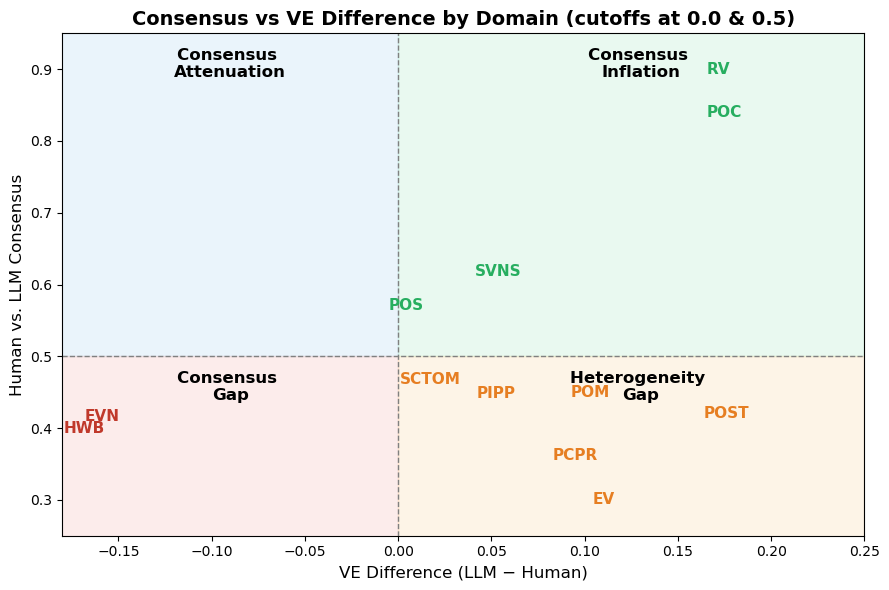

In [18]:
fig, ax = plt.subplots(figsize=(9,6))

ax.axhline(y_cut, color="gray", linestyle="--", linewidth=1)
ax.axvline(x_cut, color="gray", linestyle="--", linewidth=1)

ax.fill_betweenx([y_cut, 1], -0.2, x_cut, color="#AED6F1", alpha=0.25)
ax.fill_betweenx([y_cut, 1], x_cut, 0.25, color="#ABEBC6", alpha=0.25)
ax.fill_betweenx([0, y_cut], -0.2, x_cut, color="#F5B7B1", alpha=0.25)
ax.fill_betweenx([0, y_cut], x_cut, 0.25, color="#FAD7A0", alpha=0.25)

texts = []
for _, row in dfagg.iterrows():
    texts.append(ax.text(row["VE_Diff"], row["CC"], row["Domain"],
                         fontsize=11, fontweight="bold", color=row["color"],
                         ha="center", va="center"))


ax.set_xlabel("VE Difference (LLM − Human)", fontsize=12)
ax.set_ylabel("Human vs. LLM Consensus", fontsize=12)
ax.set_title("Consensus vs VE Difference by Domain (cutoffs at 0.0 & 0.5)", fontsize=14, weight="bold")

ax.text(-0.09, 0.93, "Consensus \nAttenuation", ha="center", va="top", fontsize=12, fontweight="bold")
ax.text( 0.13, 0.93, "Consensus \nInflation",   ha="center", va="top", fontsize=12, fontweight="bold")
ax.text(-0.09, 0.48, "Consensus \nGap",         ha="center", va="top", fontsize=12, fontweight="bold")
ax.text( 0.13, 0.48, "Heterogeneity \nGap",     ha="center", va="top", fontsize=12, fontweight="bold")

ax.set_ylim(0.25, 0.95)
ax.set_xlim(-0.18, 0.25)

plt.tight_layout()
plt.show()